In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import skew
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Bật tính năng hiển thị biểu đồ inline chất lượng cao trong Notebook
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
warnings.filterwarnings("ignore")

# ─── Cấu hình Giao diện Gợi cảm (Dark Theme Config) ───────────────────────────
PALETTE        = ["#4C9BE8", "#F4845F", "#2EC4B6", "#E71D36", "#FF9F1C", "#6A0572"]
BG             = "#0F1117"
CARD           = "#1C1F2E"
TEXT           = "#E8EAF0"
GRID           = "#2A2D3E"
SEGMENT_COLORS = {"Budget": "#4C9BE8", "Mid-range": "#2EC4B6", "Flagship": "#F4845F"}

FEATURES = ["antutu_11", "RAM_max", "ROM_max", "Battery", "Refresh Rate", "Screen Size"]
FEATURE_LABELS = {
    "antutu_11":    "Antutu Score",
    "RAM_max":       "RAM (GB)",
    "ROM_max":       "ROM (GB)",
    "Battery":       "Battery (mAh)",
    "Refresh Rate":  "Screen Hz",
    "Screen Size":   "Screen (inch)",
}

plt.rcParams.update({
    "figure.facecolor":  BG,
    "axes.facecolor":    CARD,
    "axes.edgecolor":    GRID,
    "axes.labelcolor":   TEXT,
    "xtick.color":       TEXT,
    "ytick.color":       TEXT,
    "text.color":        TEXT,
    "grid.color":        GRID,
    "grid.linewidth":    0.6,
    "font.family":       "DejaVu Sans",
    "font.size":         11,
})

# ─── Cấu hình Đường dẫn Dữ liệu ───────────────────────────────────────────────
DATA_PATH = "preprocess_1.csv" # Thay đổi đường dẫn file dữ liệu của bạn tại đây

In [3]:
DATA_PATH = 'preprocess_1.csv'

In [4]:
def load_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    return df[FEATURES + ["Name", "Brand"]].copy()

def log_transform(df: pd.DataFrame) -> pd.DataFrame:
    """Log1p-transform right-skewed features (|skew| > 0.75)."""
    df = df.copy()
    log_cols = []
    for col in FEATURES:
        s = skew(df[col].dropna())
        if abs(s) > 0.75:
            df[f"log_{col}"] = np.log1p(df[col])
            log_cols.append(col)
            print(f"  [log] {col:20s}  skew={s:+.2f}  → log1p applied")
        else:
            df[f"log_{col}"] = df[col]
            print(f"  [ok ] {col:20s}  skew={s:+.2f}  → kept as-is")
    return df, log_cols

# Thực thi nạp và chuyển đổi phân phối
print("[1/2] Loading dataset...")
df_raw = load_data(DATA_PATH)
print(f"  Shape: {df_raw.shape}")

print("\n[2/2] Running log-transform check...")
df_log, log_cols = log_transform(df_raw)
LOG_FEATURES = [f"log_{f}" for f in FEATURES]

[1/2] Loading dataset...
  Shape: (578, 8)

[2/2] Running log-transform check...
  [log] antutu_11             skew=+1.58  → log1p applied
  [ok ] RAM_max               skew=+0.44  → kept as-is
  [log] ROM_max               skew=+3.50  → log1p applied
  [log] Battery               skew=+1.18  → log1p applied
  [log] Refresh Rate          skew=+13.37  → log1p applied
  [log] Screen Size           skew=+1.36  → log1p applied


### CORRELATION HEATMAP

In [5]:
def plot_correlation_heatmap(df: pd.DataFrame, ax: plt.Axes):
    sub = df[FEATURES].rename(columns=FEATURE_LABELS)
    corr = sub.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    cmap = sns.diverging_palette(220, 20, as_cmap=True)

    sns.heatmap(
        corr, mask=mask, cmap=cmap, annot=True, fmt=".2f",
        linewidths=0.5, linecolor=GRID, square=True,
        vmin=-1, vmax=1, center=0,
        annot_kws={"size": 10, "weight": "bold"},
        ax=ax,
        cbar_kws={"shrink": 0.75, "label": "Pearson r"},
    )
    ax.set_title("① Feature Correlation Heatmap", fontsize=14, fontweight="bold", color=TEXT, pad=12)
    ax.tick_params(axis="x", rotation=30, labelsize=9)
    ax.tick_params(axis="y", rotation=0,  labelsize=9)

    corr_no_diag = corr.where(~mask)
    max_idx = corr_no_diag.stack().idxmax()
    ax.text(0.02, -0.14, f"Strongest: {max_idx[0]} ↔ {max_idx[1]} (r={corr_no_diag.loc[max_idx]:.2f})",
            transform=ax.transAxes, fontsize=9, color="#F4845F", style="italic")

def plot_kde_distributions(df: pd.DataFrame, log_cols: list, axes):
    for i, col in enumerate(FEATURES):
        ax = axes[i // 3][i % 3]
        data = df[col].dropna()
        s = skew(data)
        transformed = col in log_cols
        color = PALETTE[i]
        
        sns.kdeplot(data, ax=ax, fill=True, color=color, alpha=0.35, linewidth=2)

        if transformed:
            ax2 = ax.twinx()
            sns.kdeplot(np.log1p(data), ax=ax2, fill=False,
                        color="#FFFFFF", alpha=0.7, linewidth=1.5, linestyle="--")
            ax2.set_ylabel("log1p", color="#AAAAAA", fontsize=8)
            ax2.tick_params(axis="y", colors="#AAAAAA", labelsize=7)

        ax.axvline(data.median(), color=color, linewidth=1.5, linestyle=":")
        ax.set_title(FEATURE_LABELS[col], fontsize=11, fontweight="bold", color=TEXT)
        ax.set_xlabel("")

        tag = f"skew={s:+.2f}"
        flag = "⚠ log1p" if transformed else "✓ ok"
        fc = "#F4845F" if transformed else "#2EC4B6"
        ax.text(0.97, 0.92, f"{tag}\n{flag}", transform=ax.transAxes,
                ha="right", va="top", fontsize=8.5, color=fc, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor=BG, alpha=0.7))
        ax.grid(True, alpha=0.3)

def plot_pca_space(components, ev, loadings, ax_scatter, ax_loadings):
    ax_scatter.scatter(components[:, 0], components[:, 1], alpha=0.5, s=18, color=PALETTE[0], edgecolors="none")
    ax_scatter.set_xlabel(f"PC1  ({ev[0]:.1%} var)", fontsize=11)
    ax_scatter.set_ylabel(f"PC2  ({ev[1]:.1%} var)", fontsize=11)
    ax_scatter.set_title(f"③ PCA Product Space\n(Total explained: {ev.sum():.1%})", fontsize=14, fontweight="bold", color=TEXT, pad=10)
    ax_scatter.axhline(0, color=GRID, linewidth=0.8)
    ax_scatter.axvline(0, color=GRID, linewidth=0.8)
    ax_scatter.grid(True, alpha=0.25)

    x = np.arange(len(loadings))
    w = 0.35
    ax_loadings.bar(x - w/2, loadings["PC1"], w, color=PALETTE[0], label="PC1", alpha=0.85)
    ax_loadings.bar(x + w/2, loadings["PC2"], w, color=PALETTE[1], label="PC2", alpha=0.85)
    ax_loadings.set_xticks(x)
    ax_loadings.set_xticklabels(loadings.index, rotation=25, ha="right", fontsize=9)
    ax_loadings.axhline(0, color=TEXT, linewidth=0.7)
    ax_loadings.set_title("PCA Loadings", fontsize=12, fontweight="bold", color=TEXT)
    ax_loadings.legend(fontsize=9)
    ax_loadings.grid(True, alpha=0.3)

def plot_kmeans(components, segment, idx, ax):
    names = ["Budget", "Mid-range", "Flagship"]
    for seg in names:
        mask = segment.loc[idx] == seg
        ax.scatter(components[mask, 0], components[mask, 1], label=f"{seg} (n={mask.sum()})",
                   color=SEGMENT_COLORS[seg], alpha=0.65, s=22, edgecolors="none")
    ax.set_xlabel("PC1", fontsize=11)
    ax.set_ylabel("PC2", fontsize=11)
    ax.set_title("④ K-Means Segmentation (K=3)\nBudget · Mid-range · Flagship", fontsize=14, fontweight="bold", color=TEXT, pad=10)
    ax.legend(fontsize=10, loc="upper left", framealpha=0.4, facecolor=CARD, edgecolor=GRID)
    ax.axhline(0, color=GRID, linewidth=0.8)
    ax.axvline(0, color=GRID, linewidth=0.8)
    ax.grid(True, alpha=0.25)

def plot_segment_profiles(df, segment, idx, ax):
    sub = df.loc[idx, FEATURES].copy()
    sub["Segment"] = segment.loc[idx].values
    means = sub.groupby("Segment")[FEATURES].mean()
    norm = (means - means.min()) / (means.max() - means.min() + 1e-9)
    norm = norm.rename(columns=FEATURE_LABELS)

    x = np.arange(len(FEATURES))
    w = 0.25
    segs = ["Budget", "Mid-range", "Flagship"]
    offsets = [-w, 0, w]

    for seg, off in zip(segs, offsets):
        vals = norm.loc[seg].values if seg in norm.index else np.zeros(len(FEATURES))
        ax.bar(x + off, vals, w, label=seg, color=SEGMENT_COLORS[seg], alpha=0.82)

    ax.set_xticks(x)
    ax.set_xticklabels(list(FEATURE_LABELS.values()), rotation=22, ha="right", fontsize=9)
    ax.set_ylabel("Normalised Mean (0–1)", fontsize=10)
    ax.set_title("Segment Feature Profiles", fontsize=12, fontweight="bold", color=TEXT)
    ax.legend(fontsize=9, framealpha=0.4, facecolor=CARD, edgecolor=GRID)
    ax.grid(True, axis="y", alpha=0.3)

In [6]:
# ─── 1. Thực thi thuật toán giảm chiều PCA ────────────────────────────────────
X = df_log[LOG_FEATURES].dropna()
idx = X.index
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)
ev = pca.explained_variance_ratio_

loadings = pd.DataFrame(
    pca.components_.T,
    index=[FEATURE_LABELS[f.replace("log_", "")] for f in LOG_FEATURES],
    columns=["PC1", "PC2"],
)
print(f"✓ PCA complete: PC1={ev[0]:.1%} | PC2={ev[1]:.1%} | Total Explained={ev.sum():.1%}")

# ─── 2. Thực thi phân tầng K-Means (K=3) ──────────────────────────────────────
km = KMeans(n_clusters=3, random_state=42, n_init=20)
labels = km.fit_predict(X_scaled)

# Sắp xếp nhãn cụm dựa trên hiệu năng AnTuTu thực tế để đảm bảo tính nhất quán
cluster_antutu = {c: df_raw.loc[idx[labels == c], "antutu_11"].mean() for c in range(3)}
sorted_clusters = sorted(cluster_antutu, key=cluster_antutu.get)
label_map = {sorted_clusters[0]: "Budget", sorted_clusters[1]: "Mid-range", sorted_clusters[2]: "Flagship"}

segment = pd.Series(labels, index=idx).map(label_map)
print(f"✓ K-Means Complete. Target groups defined.")

✓ PCA complete: PC1=46.0% | PC2=19.9% | Total Explained=65.9%
✓ K-Means Complete. Target groups defined.


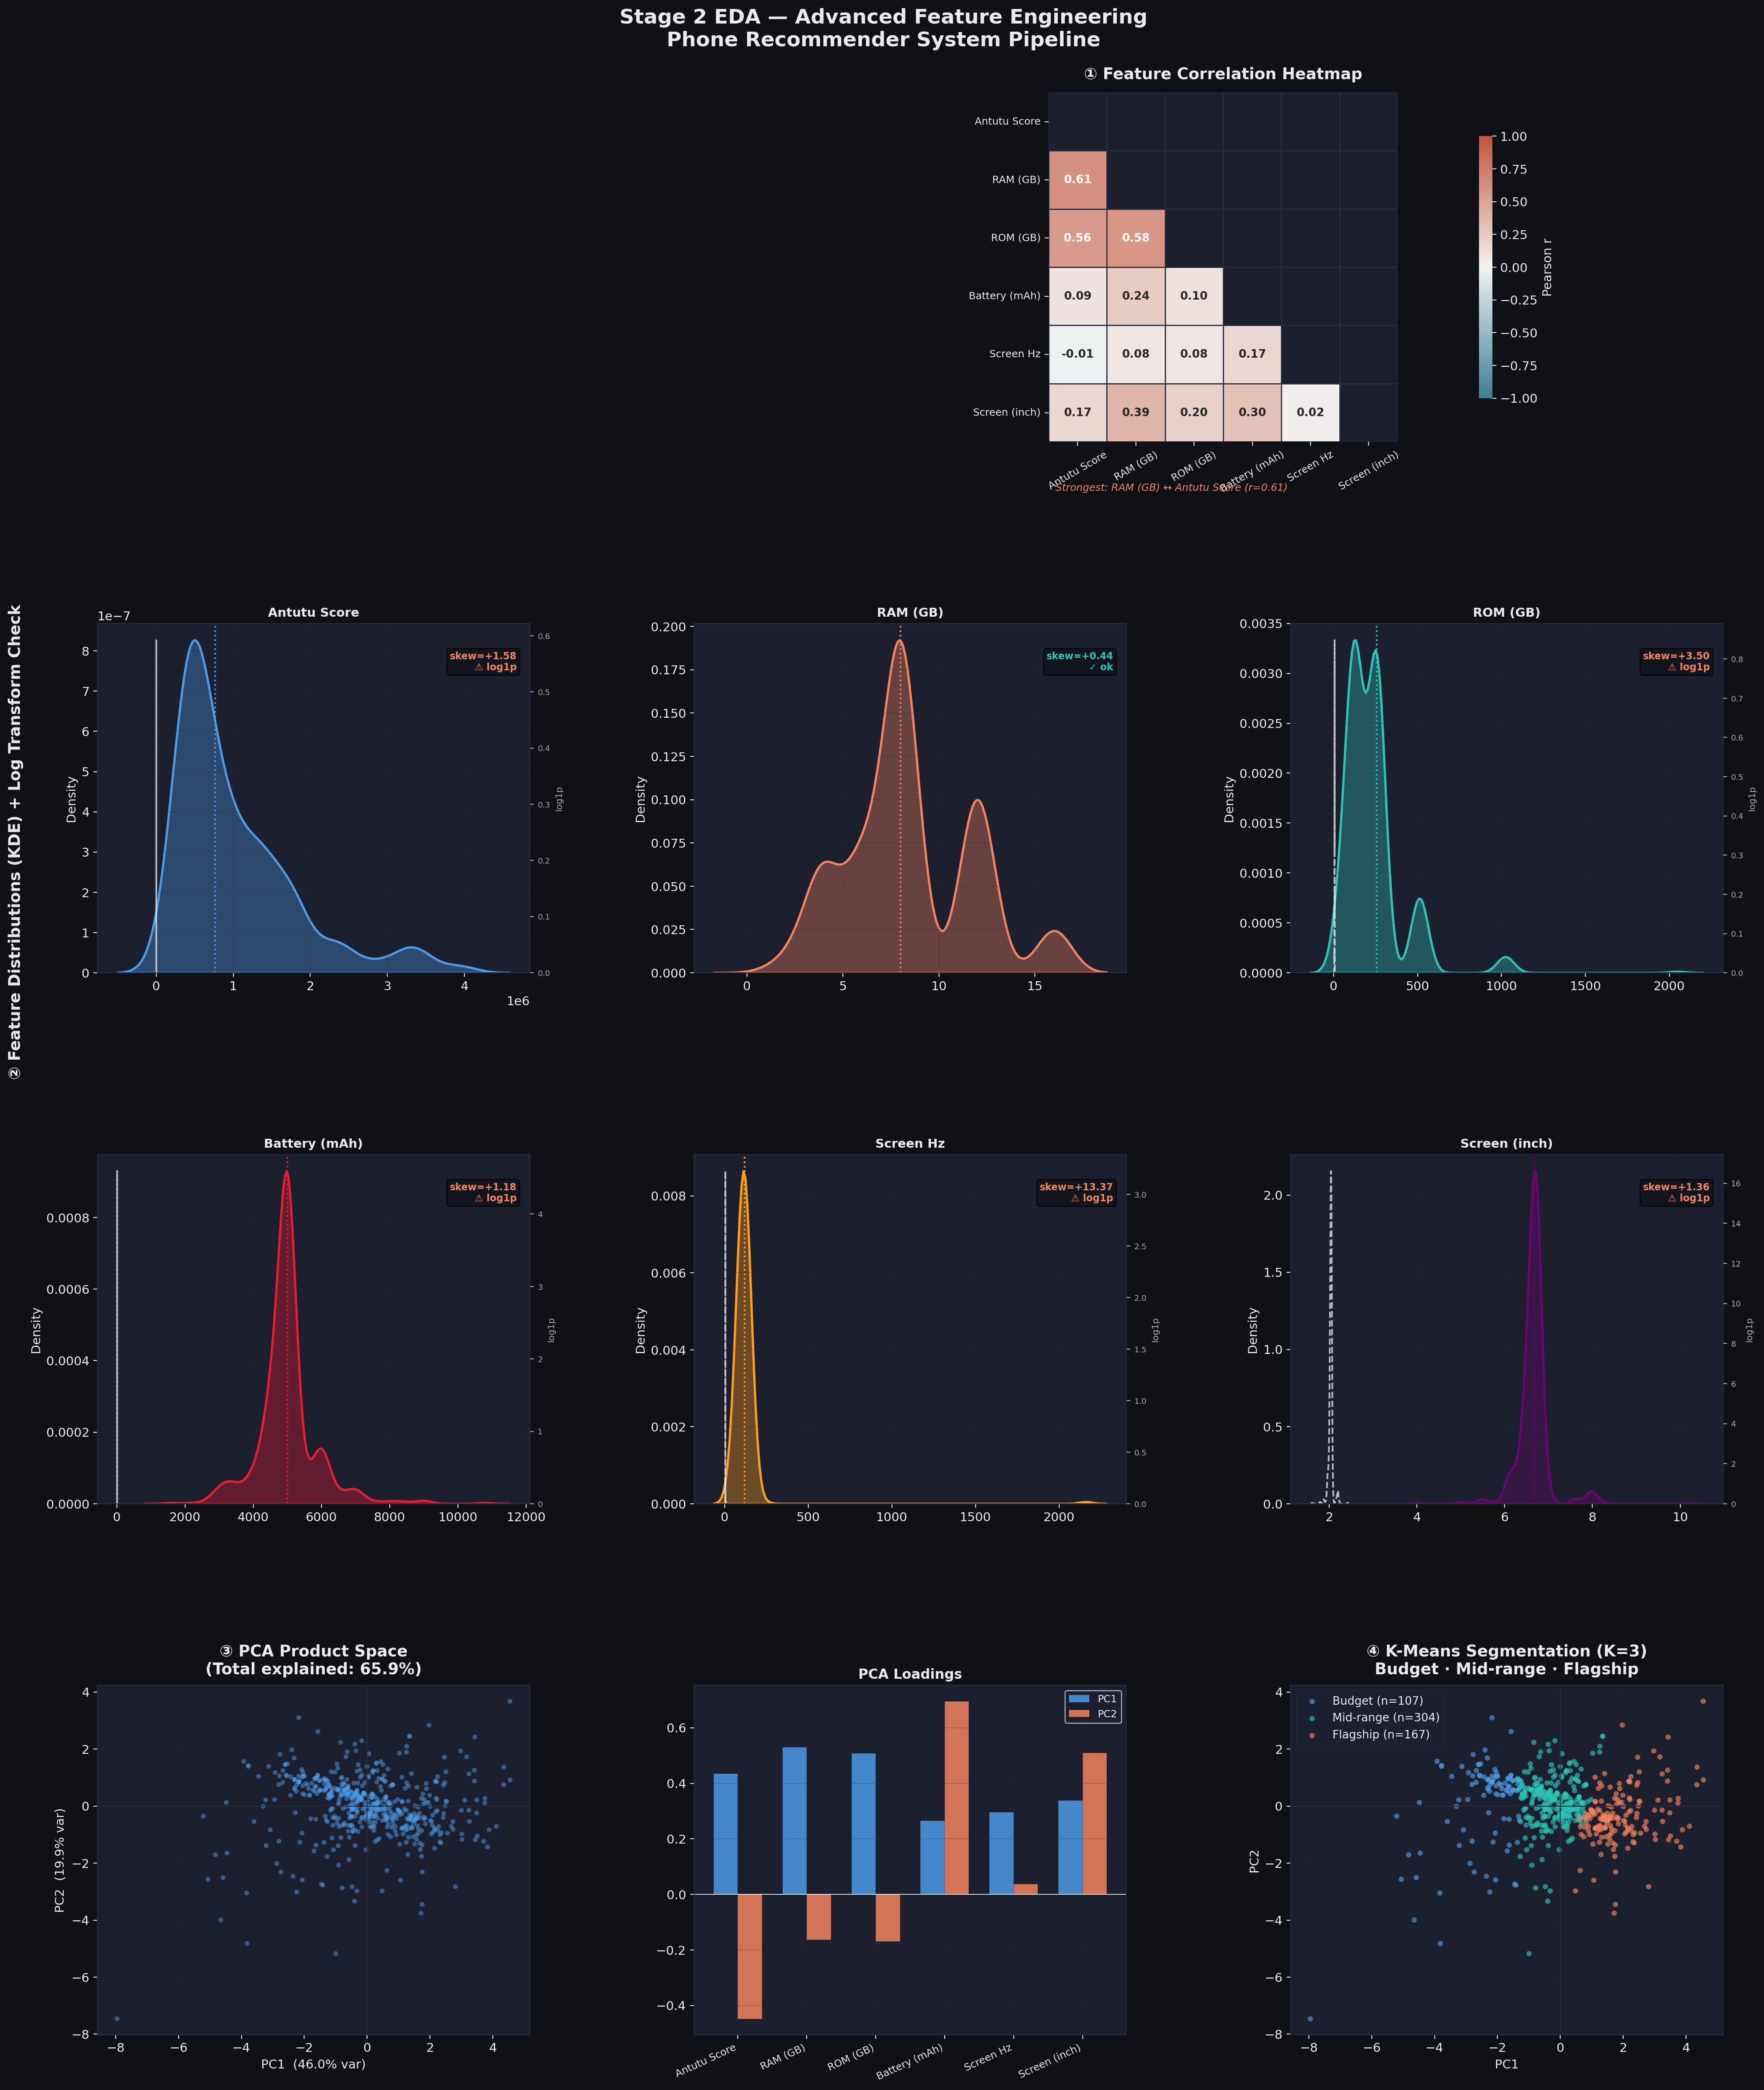

In [7]:
# Khởi tạo khung lưới đồ họa lớn
fig = plt.figure(figsize=(22, 26), facecolor=BG)
fig.suptitle("Stage 2 EDA — Advanced Feature Engineering\nPhone Recommender System Pipeline", 
             fontsize=18, fontweight="bold", color=TEXT, y=0.99)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.38, top=0.95, bottom=0.03, left=0.06, right=0.97)

# ── Row 0: Heatmap Ma trận tương quan ──
ax_heat = fig.add_subplot(gs[0, :])
plot_correlation_heatmap(df_raw, ax_heat)

# ── Row 1 & 2: Phân phối KDE & Kiểm tra Log Transform ──
kde_axes = [[fig.add_subplot(gs[1, c]) for c in range(3)],
            [fig.add_subplot(gs[2, c]) for c in range(3)]]
plot_kde_distributions(df_raw, log_cols, kde_axes)
fig.text(0.01, 0.595, "② Feature Distributions (KDE) + Log Transform Check",
         fontsize=14, fontweight="bold", color=TEXT, va="center", rotation=90)

# ── Row 3: Không gian PCA và các Cụm Phân Phối ──
ax_pca  = fig.add_subplot(gs[3, 0])
ax_load = fig.add_subplot(gs[3, 1])
ax_km   = fig.add_subplot(gs[3, 2])

plot_pca_space(components, ev, loadings, ax_pca, ax_load)
plot_kmeans(components, segment, idx, ax_km)

# Hiển thị trực tiếp đồ thị lên giao diện Jupyter Notebook
plt.show()

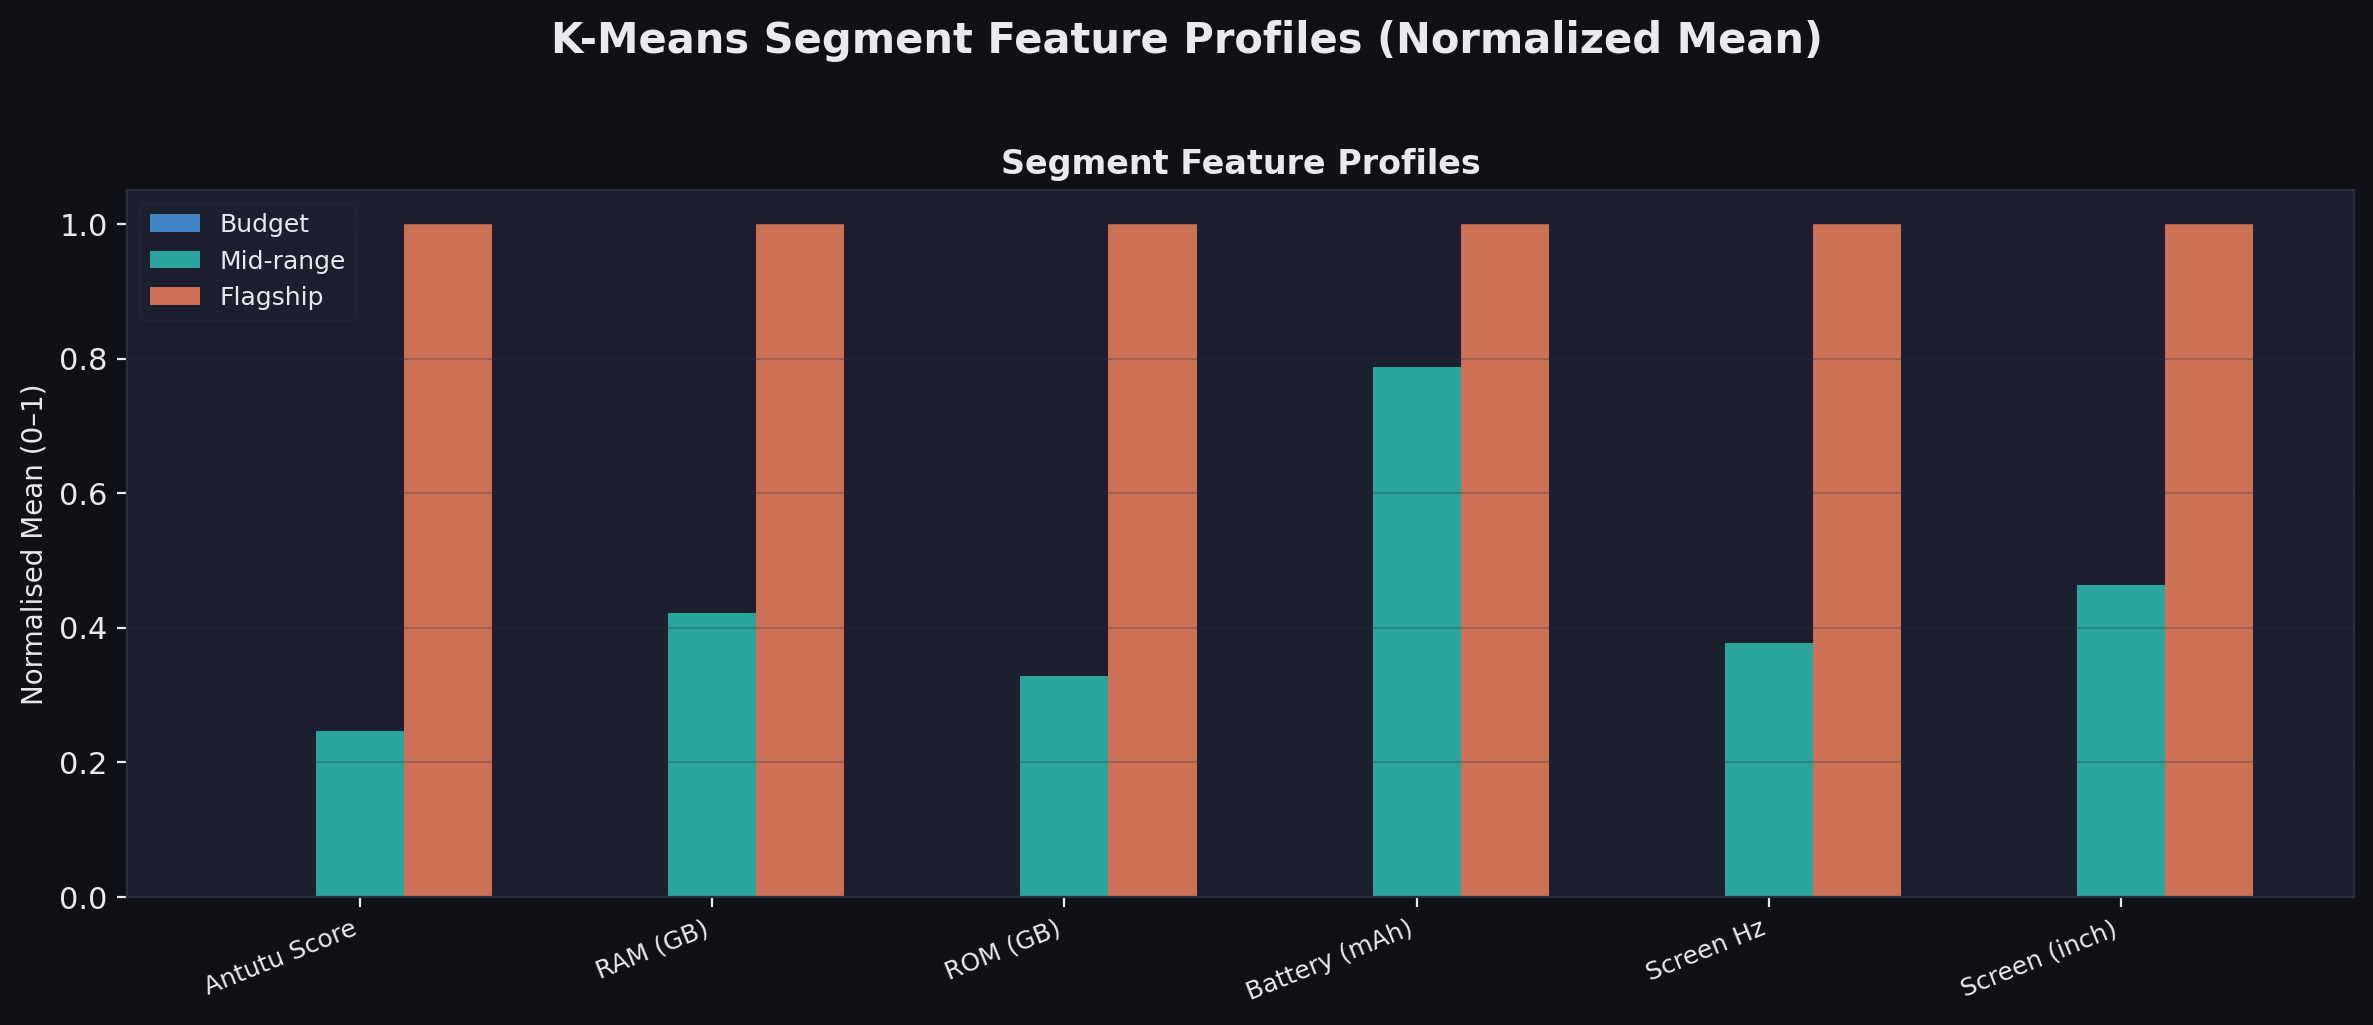

In [8]:
fig, ax = plt.subplots(figsize=(12, 5), facecolor=BG)
ax.set_facecolor(CARD)
plot_segment_profiles(df_raw, segment, idx, ax)
fig.suptitle("K-Means Segment Feature Profiles (Normalized Mean)", fontsize=15, fontweight="bold", color=TEXT, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
print("=" * 70)
print("              ENGINEERING INSIGHTS FOR RECOMMENDER SYSTEM")
print("=" * 70)

corr = df_raw[FEATURES].corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
top_pair = upper.stack().abs().idxmax()
print(f"\n[1. Correlation Analysis]")
print(f"  ▸ Strongest collinearity pair: {top_pair[0]} ↔ {top_pair[1]} (r = {upper.loc[top_pair]:.3f})")
print(f"  ▸ Architecture Strategy: Consider removing or regularizing highly collinear dimensions for KNN stability.")

print(f"\n[2. Distribution & Log Transformation]")
for col in FEATURES:
    s = skew(df_raw[col].dropna())
    flag = "✓ log1p applied (balanced)" if col in log_cols else "— kept as-is (linear scale)"
    print(f"  ▸ {col:15s} | Raw Skewness = {s:+.2f} | Action: {flag}")

print(f"\n[3. Principal Component Analysis]")
print(f"  ▸ PC1 Variance: {ev[0]:.1%} (Represents Overall Performance Axis)")
print(f"  ▸ PC2 Variance: {ev[1]:.1%} (Represents Ergonomics & Screen/Battery Axis)")
print(f"  ▸ Accumulated Variance: {ev.sum():.1%} → 2 PCs are solid for downstream distance matrix calculation.")
print(f"  ▸ Strongest Driver for PC1: {loadings['PC1'].abs().idxmax()}")
print(f"  ▸ Strongest Driver for PC2: {loadings['PC2'].abs().idxmax()}")

counts = segment.loc[idx].value_counts()
print(f"\n[4. Natural Segmentation (K-Means K=3)]")
for seg in ["Budget", "Mid-range", "Flagship"]:
    print(f"  ▸ {seg:12s}: {counts.get(seg, 0):4d} active phone profiles mapped")
print("\n💡 RECOMMENDER BLUEPRINT:")
print("  These 3 segment categories serve as a 'hard business filter rule' before computing")
print("  item-to-item Cosine Similarity. The final feature space is clean and ready for production.")
print("=" * 70)

              ENGINEERING INSIGHTS FOR RECOMMENDER SYSTEM

[1. Correlation Analysis]
  ▸ Strongest collinearity pair: antutu_11 ↔ RAM_max (r = 0.614)
  ▸ Architecture Strategy: Consider removing or regularizing highly collinear dimensions for KNN stability.

[2. Distribution & Log Transformation]
  ▸ antutu_11       | Raw Skewness = +1.58 | Action: ✓ log1p applied (balanced)
  ▸ RAM_max         | Raw Skewness = +0.44 | Action: — kept as-is (linear scale)
  ▸ ROM_max         | Raw Skewness = +3.50 | Action: ✓ log1p applied (balanced)
  ▸ Battery         | Raw Skewness = +1.18 | Action: ✓ log1p applied (balanced)
  ▸ Refresh Rate    | Raw Skewness = +13.37 | Action: ✓ log1p applied (balanced)
  ▸ Screen Size     | Raw Skewness = +1.36 | Action: ✓ log1p applied (balanced)

[3. Principal Component Analysis]
  ▸ PC1 Variance: 46.0% (Represents Overall Performance Axis)
  ▸ PC2 Variance: 19.9% (Represents Ergonomics & Screen/Battery Axis)
  ▸ Accumulated Variance: 65.9% → 2 PCs are solid for

In [11]:
def print_insights(df, log_cols, ev, loadings, segment, idx):
    print("\n" + "=" * 60)
    print("  ENGINEERING INSIGHTS")
    print("=" * 60)
 
    corr = df[FEATURES].corr()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    top_pair = upper.stack().abs().idxmax()
    print(f"\n[Correlation]")
    print(f"  Strongest pair : {top_pair[0]} ↔ {top_pair[1]}")
    print(f"  r = {upper.loc[top_pair]:.3f}")
    print(f"  → Consider removing one for KNN (collinearity risk)")
 
    print(f"\n[Log Transform]")
    for col in FEATURES:
        s = skew(df[col])
        flag = "✓ log1p applied" if col in log_cols else "— kept as-is"
        print(f"  {col:20s}  skew={s:+.2f}  {flag}")
 
    print(f"\n[PCA]")
    print(f"  PC1 explains  {ev[0]:.1%}  (overall performance axis)")
    print(f"  PC2 explains  {ev[1]:.1%}  (screen/battery axis)")
    print(f"  Total         {ev.sum():.1%}  → 2 PCs sufficient for visualisation")
    print(f"  Top PC1 driver: {loadings['PC1'].abs().idxmax()}")
    print(f"  Top PC2 driver: {loadings['PC2'].abs().idxmax()}")
 
    counts = segment.loc[idx].value_counts()
    print(f"\n[K-Means K=3]")
    for seg in ["Budget", "Mid-range", "Flagship"]:
        print(f"  {seg:12s}: {counts.get(seg, 0):4d} phones")
    print("\n  Segment is a clean proxy for price tier — use as")
    print("  a metadata filter layer in the recommender.\n")